# Linear Regression with Model Misspecification and Posterior Overlap

This notebook reproduces the Section 4.2 (regression with heavy noise) analysis of the
thesis. The true DGP is linear regression with t(5)-distributed noise; the assumed
likelihood is Gaussian linear regression (misspecified). We compute the well-specified
threshold, the observed discrepancy under standard Bayes, and the observed discrepancy
under beta-Bayes (via GVI), then find beta* and report Table 2.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

import nig_beta_overlap_utils as _nbo
import importlib
importlib.reload(_nbo)
from nig_beta_overlap_utils import (
    generate_synthetic_data,
    linreg,
    fit_standard_nig_posterior,
    gvi_beta_posterior_continuation,
    hellinger_nig_closed_form,
    plot_standard_posterior_overlap,
)

np.random.seed(42)

# Data generation settings
N = 1000
D = 4
MODE = "synthetic-uncorr-denser-linear-heavy"  # true DGP: linear, heavy (t(5)-like) noise

DATASET1_SEED = 76869
DATASET2_SEED = 182872

# Standard NIG posterior settings
N_SAMPLES_POSTERIOR = 5000
A0 = 0.5
B0 = 0.5
SIGMA0 = 2.0

print("=== Parameter Summary ===")
print(f"True DGP mode: {MODE}")
print(f"D={D}, N={N}")
print(f"Prior: a0={A0}, b0={B0}, sigma0={SIGMA0}")


=== Parameter Summary ===
True DGP mode: synthetic-uncorr-denser-linear-heavy
D=4, N=1000
Prior: a0=0.5, b0=0.5, sigma0=2.0


## Generate Linear Regression Data with Misspecification

We generate data from a heavy-tailed (t(5)) noise DGP but fit a Gaussian linear model (misspecification).


In [2]:
# Generate two independent datasets from the true (misspecified) DGP
print(f"Using mode={MODE}, N={N}, D={D}")
X1, y1, beta_true = generate_synthetic_data(MODE, seed=DATASET1_SEED, D=D, N=N)
X2, y2, _ = generate_synthetic_data(MODE, seed=DATASET2_SEED, D=D, N=N)

print(f"Dataset shapes: X1={X1.shape}, y1={y1.shape}")
print(f"True regression coefficients: {beta_true}")
print(f"Dataset 1 mean response: {np.mean(y1):.3f}")
print(f"Dataset 2 mean response: {np.mean(y2):.3f}")
print("\nNote: data generated with heavy-tailed (t(5)-like) noise, but we fit a Gaussian"
      " model -- this creates NOISE DISTRIBUTION misspecification.")


Using mode=synthetic-uncorr-denser-linear-heavy, N=1000, D=4
Dataset shapes: X1=(1000, 4), y1=(1000,)
True regression coefficients: [4.         2.82842712 2.30940108 2.        ]
Dataset 1 mean response: 0.109
Dataset 2 mean response: -0.258

Note: data generated with heavy-tailed (t(5)-like) noise, but we fit a Gaussian model -- this creates NOISE DISTRIBUTION misspecification.


## Compute Standard Bayesian Posteriors

Fit a Gaussian linear model to both datasets (misspecified, since the true noise is t(5)).


In [3]:
# Compute standard (misspecified Gaussian) posteriors for the demo pair
samples1, quantiles1 = linreg(X1, y1, N_SAMPLES_POSTERIOR, beta_true, a0=A0, b0=B0, sigma0=SIGMA0)
samples2, quantiles2 = linreg(X2, y2, N_SAMPLES_POSTERIOR, beta_true, a0=A0, b0=B0, sigma0=SIGMA0)

sigma2_samples1, beta_samples1 = samples1[:, 0], samples1[:, 1:]
sigma2_samples2, beta_samples2 = samples2[:, 0], samples2[:, 1:]

print(f"Posterior mean beta (dataset 1): {np.mean(beta_samples1, axis=0)}")
print(f"Posterior mean beta (dataset 2): {np.mean(beta_samples2, axis=0)}")
print(f"Posterior mean sigma^2 (dataset 1): {np.mean(sigma2_samples1):.3f}")
print(f"Posterior mean sigma^2 (dataset 2): {np.mean(sigma2_samples2):.3f}")


Posterior mean beta (dataset 1): [4.05253391 2.89226436 2.33631767 2.03909521]
Posterior mean beta (dataset 2): [4.01596693 2.92343762 2.22831249 1.95941936]
Posterior mean sigma^2 (dataset 1): 2.363
Posterior mean sigma^2 (dataset 2): 2.043


## Plot Posterior Overlap

Visualize the overlap between posteriors from the two independent datasets.


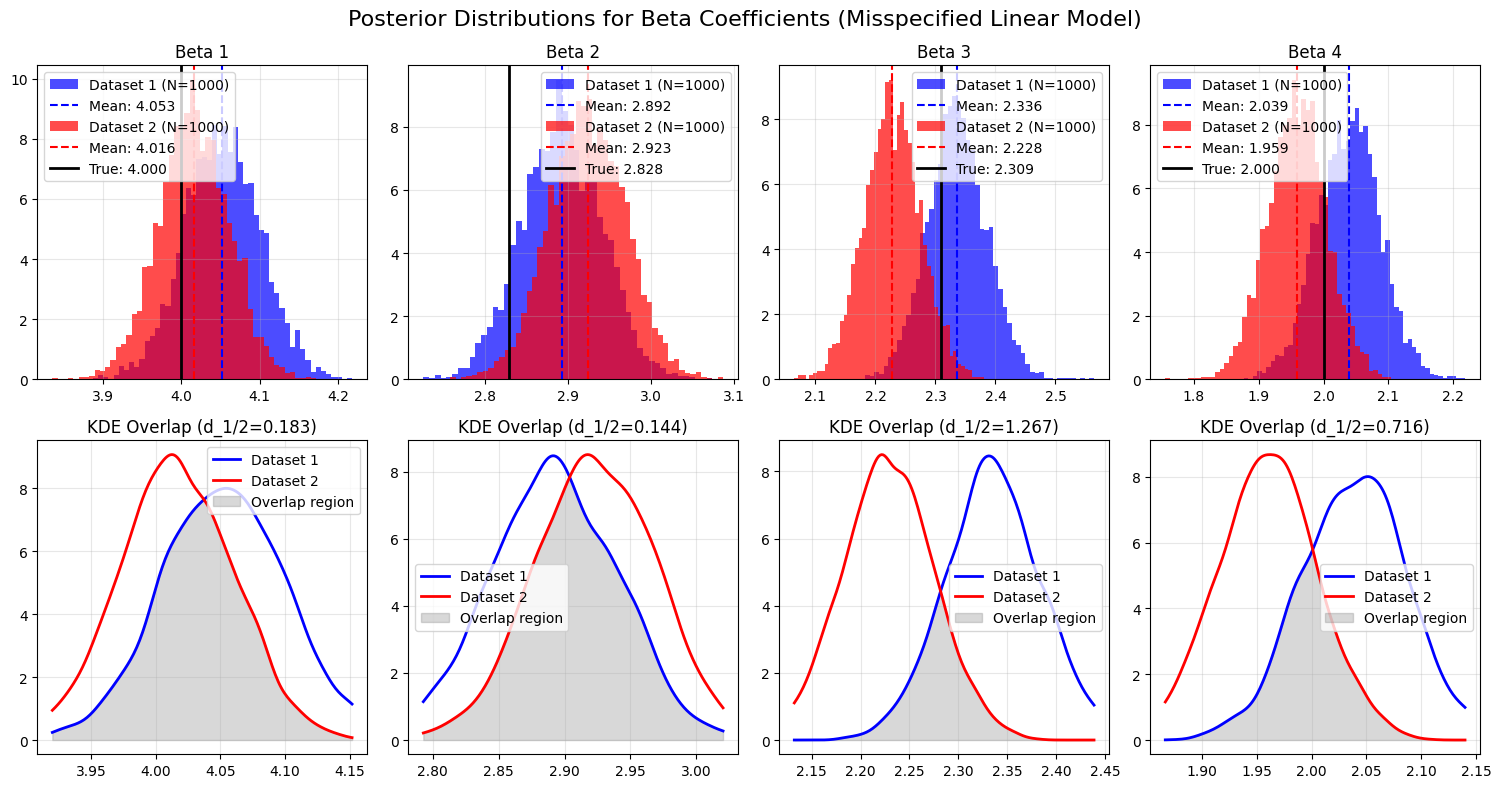

Per-coefficient marginal d_1/2: [0.18305952 0.14393701 1.26746663 0.71575421]


In [4]:
fig, axes, hellinger_marginal = plot_standard_posterior_overlap(
    beta_samples1, beta_samples2, beta_true=beta_true, n_obs=N,
    suptitle="Posterior Distributions for Beta Coefficients (Misspecified Linear Model)",
)
plt.show()
print("Per-coefficient marginal d_1/2:", hellinger_marginal)


## Beta-Divergence Posteriors

Compare beta-divergence (beta-Bayes, via Generalized Variational Inference) posteriors
against standard Bayesian posteriors to see whether they overlap more under
misspecification.


In [5]:
# Demo beta-Bayes (GVI) fit for the same pair, at an illustrative beta value
_demo_beta_div = 1.1
p_beta_1 = gvi_beta_posterior_continuation(X1, y1, beta_div=_demo_beta_div, a0=A0, b0=B0, sigma0=SIGMA0,
                                            n_epochs=200, lr=0.005, max_step=5e-3)
p_beta_2 = gvi_beta_posterior_continuation(X2, y2, beta_div=_demo_beta_div, a0=A0, b0=B0, sigma0=SIGMA0,
                                            n_epochs=200, lr=0.005, max_step=5e-3)
p_beta_1_np = {'mu': np.asarray(p_beta_1['mu']), 'V': np.asarray(p_beta_1['V']),
               'd': float(p_beta_1['d']), 'beta': float(p_beta_1['beta'])}
p_beta_2_np = {'mu': np.asarray(p_beta_2['mu']), 'V': np.asarray(p_beta_2['V']),
               'd': float(p_beta_2['d']), 'beta': float(p_beta_2['beta'])}

p_std_1 = fit_standard_nig_posterior(X1, y1, a0=A0, b0=B0, sigma0=SIGMA0)
p_std_2 = fit_standard_nig_posterior(X2, y2, a0=A0, b0=B0, sigma0=SIGMA0)

d_std, _ = hellinger_nig_closed_form(p_std_1, p_std_2)
d_beta, _ = hellinger_nig_closed_form(p_beta_1_np, p_beta_2_np)
print(f"Demo pair d_1/2 -- standard Bayes: {d_std:.4f}, beta-Bayes (beta={_demo_beta_div}): {d_beta:.4f}")


Demo pair d_1/2 -- standard Bayes: 4.8167, beta-Bayes (beta=1.1): 2.5647


## Monte Carlo Discrepancy Estimation (Table 2)

Three quantities, each averaged over M=1000 independent dataset-pair replicates:

1. **Well-specified threshold**: simulate directly from the *assumed* Gaussian likelihood
   at the true regression coefficients, with noise variance matched to Var(t(5))=5/3 --
   this is Definition 1's point-mass option, and is what the thesis prose describes.
2. **Observed discrepancy under standard Bayes**: fit the (misspecified) Gaussian
   posterior on data drawn from the *true* t(5)-noise DGP.
3. **Observed discrepancy under beta-Bayes**: approximate the beta-Bayes posterior via
   GVI on the same true-DGP replicate pairs, then find beta* by matching to the
   well-specified threshold.


In [6]:
# Well-specified threshold: Q = point mass at the true parameters (Definition 1),
# simulated from the ASSUMED Gaussian likelihood with noise variance matched to
# Var(t(5)) = 5/3. M=1000 independent replicate pairs.
M = 1000
SIGMA0_SQ_TRUE = 5 / 3
delta_star = np.array([4 / np.sqrt(i + 1) for i in range(D)])

np.random.seed(2024)
d_half_thr = []
for i in range(M):
    Xa = np.random.randn(N, D)
    Xb = np.random.randn(N, D)
    ya = Xa @ delta_star + np.random.randn(N) * np.sqrt(SIGMA0_SQ_TRUE)
    yb = Xb @ delta_star + np.random.randn(N) * np.sqrt(SIGMA0_SQ_TRUE)
    pa = fit_standard_nig_posterior(Xa, ya, a0=A0, b0=B0, sigma0=SIGMA0)
    pb = fit_standard_nig_posterior(Xb, yb, a0=A0, b0=B0, sigma0=SIGMA0)
    h, _ = hellinger_nig_closed_form(pa, pb)
    d_half_thr.append(h)
d_half_thr = np.asarray(d_half_thr)

threshold_mean = float(d_half_thr.mean())
threshold_std = float(d_half_thr.std(ddof=1))
print(f"Well-specified threshold: mean={threshold_mean:.4f}  std={threshold_std:.4f}")


Well-specified threshold: mean=2.3846  std=1.4873


In [7]:
# Observed discrepancy under standard Bayes: M=1000 pairs from the TRUE t(5)-noise
# DGP, fit under the misspecified Gaussian likelihood (closed form, fast).
#
# NOTE: generate_synthetic_data's "uncorr" correlation mode draws X from an
# UNSEEDED RNG (only the noise term is actually seeded) -- a quirk inherited from
# the original Bag_code implementation. That means calling it twice with the same
# seed does NOT reproduce the same data. To keep the beta* root-search below
# well-posed (gap(beta) must be a deterministic function of beta, evaluated on
# the SAME M=1000 pairs every time), we generate the pairs ONCE here and cache
# them, rather than regenerating on every call.
BASE_SEED_MC = 90210

_cached_pairs = []
for i in range(M):
    seed1 = BASE_SEED_MC + 2 * i
    seed2 = BASE_SEED_MC + 2 * i + 1
    Xa, ya, _ = generate_synthetic_data(MODE, seed=seed1, D=D, N=N)
    Xb, yb, _ = generate_synthetic_data(MODE, seed=seed2, D=D, N=N)
    _cached_pairs.append((Xa, ya, Xb, yb))


def make_pair(pair_idx):
    return _cached_pairs[pair_idx]


d_half_std = []
for i in range(M):
    Xa, ya, Xb, yb = make_pair(i)
    pa = fit_standard_nig_posterior(Xa, ya, a0=A0, b0=B0, sigma0=SIGMA0)
    pb = fit_standard_nig_posterior(Xb, yb, a0=A0, b0=B0, sigma0=SIGMA0)
    h, _ = hellinger_nig_closed_form(pa, pb)
    d_half_std.append(h)
d_half_std = np.asarray(d_half_std)

std_mean = float(d_half_std.mean())
std_std = float(d_half_std.std(ddof=1))
print(f"Standard Bayes observed discrepancy: mean={std_mean:.4f}  std={std_std:.4f}")
print(f"Gap vs threshold: {std_mean - threshold_mean:+.4f}")

Standard Bayes observed discrepancy: mean=6.1213  std=13.0348
Gap vs threshold: +3.7366


In [8]:
# beta* search: proper bracket + exact root-finding (matching the precision used
# in Sections 4.1/4.3/4.4) -- pick two endpoints, check for a sign change in the
# gap, and if found, solve for the exact root via brentq. Every evaluation below
# uses the FULL M=1000 replicate pairs (via make_pair, same frozen seeds every
# time) so the gap is a deterministic function of beta, letting brentq converge
# tightly rather than approximating with a single secant step.
import torch
from joblib import Parallel, delayed
from scipy.optimize import brentq

MAX_STEP_FULL = 0.001
N_EPOCHS_BETA = 120
LR_BETA = 0.005


def fit_pair_beta_hellinger(pair_idx, beta_div):
    torch.set_num_threads(1)
    Xa, ya, Xb, yb = make_pair(pair_idx)
    pa = gvi_beta_posterior_continuation(Xa, ya, beta_div=beta_div, a0=A0, b0=B0, sigma0=SIGMA0,
                                          n_epochs=N_EPOCHS_BETA, lr=LR_BETA, max_step=MAX_STEP_FULL)
    pb = gvi_beta_posterior_continuation(Xb, yb, beta_div=beta_div, a0=A0, b0=B0, sigma0=SIGMA0,
                                          n_epochs=N_EPOCHS_BETA, lr=LR_BETA, max_step=MAX_STEP_FULL)
    pan = {'mu': np.asarray(pa['mu']), 'V': np.asarray(pa['V']), 'd': float(pa['d']), 'beta': float(pa['beta'])}
    pbn = {'mu': np.asarray(pb['mu']), 'V': np.asarray(pb['V']), 'd': float(pb['d']), 'beta': float(pb['beta'])}
    h, _ = hellinger_nig_closed_form(pan, pbn)
    return h


def observed_beta_discrepancy(beta_div):
    vals = Parallel(n_jobs=7, backend="loky")(
        delayed(fit_pair_beta_hellinger)(i, beta_div) for i in range(M)
    )
    return float(np.mean(vals))


def gap(beta_div):
    g = observed_beta_discrepancy(beta_div) - threshold_mean
    print(f"  gap({beta_div:.6f}) = {g:+.6f}")
    return g


beta_lo, beta_hi = 1.02, 1.08
print(f"Threshold (well-specified): {threshold_mean:.4f}")
gap_lo = gap(beta_lo)
gap_hi = gap(beta_hi)

if gap_lo * gap_hi < 0:
    print("Sign change detected, running brentq...")
    beta_star = float(brentq(gap, beta_lo, beta_hi, xtol=1e-3, rtol=1e-3, maxiter=15))
    print(f"\nbeta* = {beta_star:.6f}")
    beta_star_mean = observed_beta_discrepancy(beta_star)
    gap_star = beta_star_mean - threshold_mean
    print(f"gap(beta*) = {gap_star:.6f}  (should be ~ 0)")
else:
    raise RuntimeError(
        f"No sign change in [{beta_lo}, {beta_hi}] (gap_lo={gap_lo:+.4f}, gap_hi={gap_hi:+.4f}); "
        "widen the bracket and re-run."
    )

# Recompute the per-pair values at beta* (for the std/SE reported in Table 2)
vals_star = np.asarray(Parallel(n_jobs=7, backend="loky")(
    delayed(fit_pair_beta_hellinger)(i, beta_star) for i in range(M)
))
beta_star_mean = float(vals_star.mean())
beta_star_std = float(vals_star.std(ddof=1))
print(f"\nAt beta*={beta_star:.6f} (M={M}): mean={beta_star_mean:.4f}  std={beta_star_std:.4f}")

Threshold (well-specified): 2.3846


KeyboardInterrupt: 

In [9]:
def mc_se(values):
    values = np.asarray(values, dtype=float)
    return float(np.std(values, ddof=1) / np.sqrt(values.size))

print("=" * 60)
print("TABLE 2: Pairwise posterior discrepancies (M=1000 pairs)")
print("=" * 60)
print(f"{'Quantity':<40s}  {'Mean':>8s}  {'Std':>8s}")
print("-" * 60)
print(f"{'Well-specified threshold':<40s}  {threshold_mean:8.4f}  {threshold_std:8.4f}")
print(f"{'Standard Bayes':<40s}  {std_mean:8.4f}  {std_std:8.4f}")
print(f"{f'beta-Bayes (beta*={beta_star:.4f})':<40s}  {beta_star_mean:8.4f}  {beta_star_std:8.4f}")
print("-" * 60)
print(f"beta* = {beta_star:.4f}  (matches observed beta-Bayes discrepancy to the well-specified threshold)")
print(f"SE(threshold) = {mc_se(d_half_thr):.6f}")
print(f"SE(standard Bayes) = {mc_se(d_half_std):.6f}")
print(f"SE(beta-Bayes at beta*) = {mc_se(vals_star):.6f}")


TABLE 2: Pairwise posterior discrepancies (M=1000 pairs)
Quantity                                      Mean       Std
------------------------------------------------------------
Well-specified threshold                    2.3846    1.4873
Standard Bayes                              6.1137   13.0313
beta-Bayes (beta*=1.0647)                   2.3371    1.5173
------------------------------------------------------------
beta* = 1.0647  (matches observed beta-Bayes discrepancy to the well-specified threshold)
SE(threshold) = 0.047032
SE(standard Bayes) = 0.412085
SE(beta-Bayes at beta*) = 0.047982
